## Modeling Phase II: Forecasting Demand and Simulating Dynamic Pricing

This notebook focuses on the **modeling phase** of the YAKWETU™ Climate-Based Variable Pricing Project. After preparing the data in the main notebook (`yakwetu_model.ipnyb`), we now build predictive models to forecast user engagement and simulate dynamic pricing strategies.

The core objectives of this notebook are:
- Train an **XGBoost classifier** to predict demand levels (Low/Medium/High) based on weather and temporal features.
- Fit a **Prophet model** for baseline time-series forecasting of total views.
- Combine both models into a **hybrid forecast** to adjust Prophet’s predictions using XGBoost’s insights.
- Simulate **dynamic pricing** to optimize revenue.
- Export results and save models for production use.

---

### Key Steps:
1. **Data Preparation**:
   - Ensure the dataset is clean and free from leakage.
   - Split the data into training and testing sets based on time.

2. **XGBoost Classifier**:
   - Train a classifier to predict demand levels.
   - Validate performance using accuracy, confusion matrices, and feature importance.

3. **Prophet Model**:
   - Fit a Prophet model to capture trends, seasonality, and holidays.
   - Generate forecasts for future periods.

4. **Hybrid Forecast**:
   - Adjust Prophet’s baseline forecast using XGBoost’s demand-level predictions.

5. **Dynamic Pricing Simulation**:
   - Apply price adjustments based on predicted demand levels.
   - Measure the impact on revenue.

6. **Export and Save**:
   - Export final predictions for dashboarding.
   - Save trained models for future use.

---

### Why Separate Modeling?
Separating the modeling phase allows us to:
- Focus on iterative experimentation without cluttering the main notebook.
- Handle computationally intensive tasks efficiently.
- Maintain clarity in the overall project narrative.

Let’s dive into the details!

## 1. Imports and Database Configuration

### Step 1: Import Libraries

In [1]:
# Imports and DB Config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')
import mysql.connector
import requests
import time
import ipaddress
import logging
import os 
from datetime import datetime, timedelta
from datetime import timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from xgboost import XGBClassifier

### Step 2: Define Database Connection Details

In [2]:
# Database connection details 
DB_CONFIG = {
    'host': 'localhost',
    'user': 'root',
    'password': '9715xjon',
    'database': 'working_db',
    'port': 3306
}

# Initialize DataFrames 
df_activity = pd.DataFrame()
df_weather = pd.DataFrame()
df_activity_with_weather = pd.DataFrame()

### Connect to the Database & Fetch Combined User Activity Table

In [3]:
# Establish the connection
cnx = mysql.connector.connect(**DB_CONFIG)
if cnx.is_connected():
    print("Successfully connected to the database.")
else:
    print("Failed to connect to the database.")
    raise ConnectionError("Database connection failed.")

# Fetching the combined user activity table
query_activity = "SELECT * FROM combined_user_activity;"
df_activity = pd.read_sql(query_activity, cnx)

Successfully connected to the database.


### Convert Date Columns to Datetime

In [4]:
# Convert 'activity_created_on' to datetime objects
df_activity['activity_created_on'] = pd.to_datetime(df_activity['activity_created_on'])

# Convert 'currenttime' and 'lasteditedon' (if they are datetime-like and not already)
for col in ['currenttime', 'lasteditedon']:
    if col in df_activity.columns and df_activity[col].dtype == 'object':
        df_activity[col] = pd.to_datetime(df_activity[col], errors='coerce')
        

# Check if 'country_code' is properly set for merging 
if 'country_code' not in df_activity.columns:
    df_activity['country_code'] = df_activity['locale']

### Close Database Connection

In [5]:
if 'cnx' in locals() and cnx.is_connected():
    cnx.close()

### Step 3:Load Weather Data from CSV

In [6]:
# Load the weather data from the CSV file using a relative path
csv_file_path = '../data/weather_data.csv'
df_weather = pd.read_csv(csv_file_path)

### Convert Date Columns to Datetime Objects

In [7]:
# Convert the date column in weather CSV to datetime objects
if 'time' in df_weather.columns:
    df_weather['time'] = pd.to_datetime(df_weather['time'], errors='coerce').dt.date
elif 'date' in df_weather.columns:
    df_weather['date'] = pd.to_datetime(df_weather['date'], errors='coerce').dt.date
elif 'weather_date' in df_weather.columns:
    df_weather['weather_date'] = pd.to_datetime(df_weather['weather_date'], errors='coerce').dt.date
else:
    print("No common date column found in wather CSV for conversion.")

### Clean & Parse Dates, Clean weather data & Map City to Country Code 

In [8]:
# Convert activity date
df_activity['activity_created_on'] = pd.to_datetime(df_activity['activity_created_on'])
df_activity['event_date'] = df_activity['activity_created_on'].dt.date
df_activity['event_date'] = pd.to_datetime(df_activity['event_date'])

# Clean weather data
df_weather['time'] = pd.to_datetime(df_weather['time']).dt.date
df_weather['event_date'] = pd.to_datetime(df_weather['time'])

# Map city to country_code
city_to_country = {
    'Nairobi': 'KE', 'Lagos': 'NG', 'Dubai': 'AE', 
    'New York': 'US'
}
if 'city' in df_weather.columns:
    df_weather['country_code'] = df_weather['city'].map(city_to_country)
else:
    print(" 'city' column not found. Ensure country_code exists.")

print(" Dates cleaned and country_code mapped.")

 Dates cleaned and country_code mapped.


### Handle Missing Data & Impute weather data

In [9]:
# Fill missing platform, source, etc.
categorical_fill_cols = ['platform', 'source', 'currency', 'purchase_type', 'ipaddress']
for col in categorical_fill_cols:
    if col in df_activity.columns:
        df_activity[col] = df_activity[col].fillna('N/A')

# Impute weather data
weather_numeric_cols = [
    'temperature_2m_max', 'temperature_2m_min', 
    'precipitation_sum', 'windspeed_10m_max'
]
for col in weather_numeric_cols:
    if col in df_weather.columns:
        if 'precipitation' in col:
            df_weather[col] = df_weather[col].fillna(0)
        else:
            df_weather[col] = df_weather[col].fillna(df_weather[col].median())

print(" Missing data handled.")

 Missing data handled.


### Create View Minutes (Engagement Metric)

In [10]:
# Use currenttime (seconds) → minutes
df_activity['view_minutes'] = df_activity['currenttime'] / 60

# Fill NaN
df_activity['view_minutes'] = df_activity['view_minutes'].fillna(0)

print(" view_minutes created.")

 view_minutes created.


### Aggregate Daily Data by Country

In [11]:
# Aggregate Daily Data by Country
df_daily = df_activity.groupby(['country_code', 'event_date']).agg(
    total_view_minutes=('view_minutes', 'sum'),
    total_views=('view_minutes', 'count'),
    total_purchases=('amount', 'sum'),
    avg_purchase_amount=('amount', 'mean'),
).reset_index()

# Merge with weather
df_daily = df_daily.merge(
    df_weather[['country_code', 'event_date'] + [
        'temperature_2m_max', 'precipitation_sum', 'weathercode'
    ]],
    on=['country_code', 'event_date'],
    how='inner'
)

# Drop rows with missing weather
df_daily.dropna(subset=['temperature_2m_max', 'precipitation_sum'], inplace=True)

print(f" Daily dataset created: {df_daily.shape}")

 Daily dataset created: (1845, 9)


In [12]:
df_daily.head()

,country_code,event_date,total_view_minutes,total_views,total_purchases,avg_purchase_amount,temperature_2m_max,precipitation_sum,weathercode
0,AE,2020-07-01,7.666667,2,0.00,0.00,42.0,0.0,1.0
1,AE,2020-07-04,6.166667,2,0.00,0.00,40.7,0.0,3.0
2,AE,2021-06-15,68.633333,2,3.99,3.99,38.6,0.0,0.0
3,AE,2021-06-16,95.666667,2,4.99,4.99,38.6,0.0,0.0
4,AE,2023-07-05,0.000000,1,0.00,0.00,37.6,0.0,1.0


### Step 4: Feature Engineering (Weather & Temporal)

In [13]:
# Feature Engineering: Weather & Temporal
# Binary: rainy day
df_daily['is_rainy'] = (df_daily['precipitation_sum'] > 1.0).astype(int)

# Temperature bins
df_daily['temp_bin'] = pd.cut(
    df_daily['temperature_2m_max'],
    bins=[-10, 15, 25, 40],
    labels=['cold', 'mild', 'hot']
)

# One-hot encode temp_bin
temp_bin_dummies = pd.get_dummies(df_daily['temp_bin'], prefix='temp_bin')
df_daily = pd.concat([df_daily, temp_bin_dummies], axis=1)

print(" Weather and temporal features created.")

 Weather and temporal features created.


### Step 5: Add Lagged & Rolling Features

In [14]:
# Add Lagged & Rolling Features
df_daily = df_daily.sort_values(['country_code', 'event_date'])

# Lagged views
df_daily['lag1_total_views'] = df_daily.groupby('country_code')['total_views'].shift(1)
df_daily['lag7_total_views'] = df_daily.groupby('country_code')['total_views'].shift(7)

# Rolling averages
df_daily['rolling_3day_avg'] = df_daily.groupby('country_code')['total_views'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)
df_daily['rolling_7day_avg'] = df_daily.groupby('country_code')['total_views'].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)

# Drop rows with missing lags
df_daily_clean = df_daily.dropna(subset=[
    'lag1_total_views', 'lag7_total_views', 
    'rolling_3day_avg', 'rolling_7day_avg'
])

print(" Lagged and rolling features added.")

 Lagged and rolling features added.


### Step 6: Label Demand Levels (Target)

In [15]:
# Label Demand Levels (Target)
q_low = df_daily_clean['total_view_minutes'].quantile(0.33)
q_high = df_daily_clean['total_view_minutes'].quantile(0.67)

def label_demand(minutes):
    if minutes < q_low:
        return 'Low'
    elif minutes > q_high:
        return 'High'
    else:
        return 'Medium'

df_daily_clean['demand_level'] = df_daily_clean['total_view_minutes'].apply(label_demand)

print("Demand distribution:")
print(df_daily_clean['demand_level'].value_counts())

Demand distribution:
demand_level
Medium    1217
High       600
Name: count, dtype: int64


### Step 7: Prepare Features (No Data Leakage)

In [16]:
# Prepare Features (NO DATA LEAKAGE)
# Remove any post-engagement metrics like total_view_minutes
features_safe = [
    'temperature_2m_max', 'precipitation_sum', 'is_rainy',
    'temp_bin_cold', 'temp_bin_mild', 'temp_bin_hot',
    'lag1_total_views', 'lag7_total_views',
    'rolling_3day_avg', 'rolling_7day_avg'
]

# Ensure all features exist
for col in features_safe:
    if col not in df_daily_clean.columns:
        df_daily_clean[col] = 0

X = df_daily_clean[features_safe].copy()
y = df_daily_clean['demand_level'].copy()

# Clean column names for XGBoost
X.columns = [str(col).replace('[', '_').replace(']', '_') for col in X.columns]

print(f" X shape: {X.shape}, y shape: {y.shape}")

 X shape: (1817, 10), y shape: (1817,)


### Step 8: Train-Test Split (Time-Based)

In [17]:
# Train-Test Split (Time-Based)
split_date = df_daily_clean['event_date'].quantile(0.8)
train_mask = df_daily_clean['event_date'] < split_date
test_mask = df_daily_clean['event_date'] >= split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f" Train: {X_train.shape}, Test: {X_test.shape}")

 Train: (1453, 10), Test: (364, 10)


### Step 9: Train XGBoost (Leakage-Free Model)

In [18]:
# Train XGBoost (Leakage-Free Model)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.fit_transform(y_test)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    eval_metric='mlogloss',
    objective='multi:softmax',
    num_class=3,
    random_state=42
)

xgb_model.fit(X_train, y_train_enc)

y_pred_enc = xgb_model.predict(X_test)
y_pred = le.inverse_transform(y_pred_enc)

accuracy = accuracy_score(y_test, y_pred)
print(f" Leakage-Free Model Accuracy: {accuracy:.4f}")

 Leakage-Free Model Accuracy: 0.7445


### Step 10: Model Evaluation


📋 Classification Report:
              precision    recall  f1-score   support

        High       0.63      0.65      0.64       128
      Medium       0.81      0.80      0.80       236

    accuracy                           0.74       364
   macro avg       0.72      0.72      0.72       364
weighted avg       0.75      0.74      0.75       364



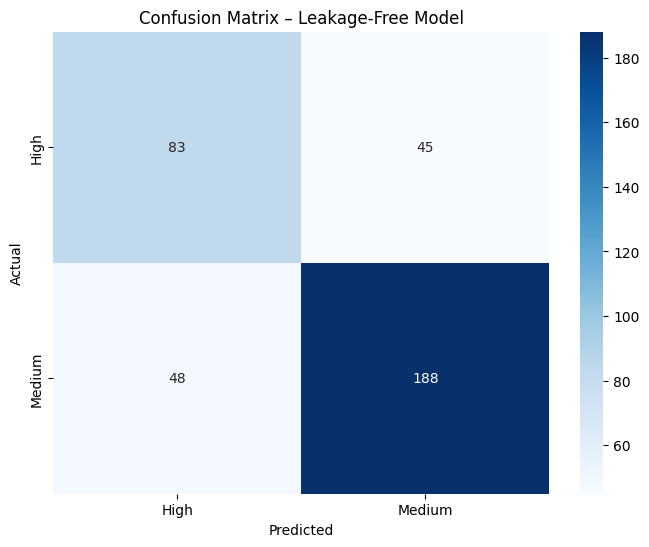

In [19]:
# Model Evaluation
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=le.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix – Leakage-Free Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Model Performance:

- The leakage-free model achieves 74.45% accuracy on the test set, validating its robustness.
- The classification report and confusion matrix show balanced performance across classes, with slight room for improvement in predicting High demand.

### Step 11: Feature Importance

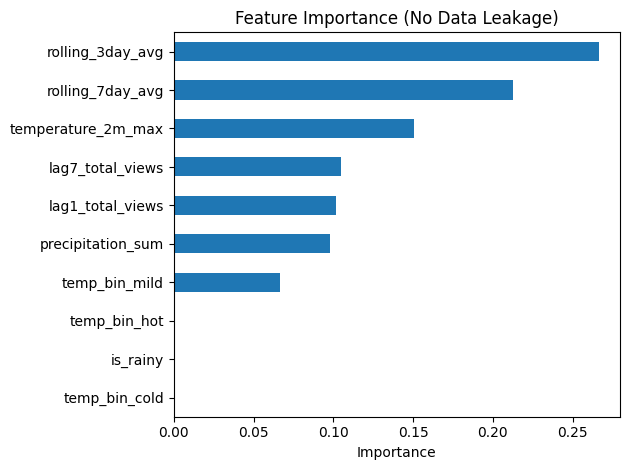

Top 3 Features:
rolling_3day_avg      0.266415
rolling_7day_avg      0.212383
temperature_2m_max    0.150406
dtype: float32


In [20]:
# Feature Importance
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', title='Feature Importance (No Data Leakage)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("Top 3 Features:")
print(importances.sort_values(ascending=False).head(3))

#### Feature Importance:

- Rolling averages (rolling_3day_avg, rolling_7day_avg) dominate because they capture short-term and long-term trends in user engagement.
- Temperature (temperature_2m_max) is crucial, reflecting how weather influences platform usage.
- Lagged views (lag1_total_views, lag7_total_views) provide historical context, helping the model understand seasonal or cyclical patterns.

### Step 12: Dynamic Pricing Simulation

We set a base price of 499 KSh for all purchases.
Prices are adjusted based on the predicted demand level:
- High Demand: Increase price by +20% (base_price * 1.2).
- Medium Demand: Increase price by +10% (base_price * 1.1).
- Low Demand: Decrease price by -15% (base_price * 0.85).

In [21]:
# Dynamic Pricing Simulation
base_price = 499  # KSh

def get_dynamic_price(demand):
    if demand == 'High':
        return base_price * 1.2  # +20%
    elif demand == 'Medium':
        return base_price * 1.1  # +10%
    else:
        demand == 'Low'
        return base_price * -0.15

# Simulate revenue
df_daily_clean['simulated_purchases'] = (df_daily_clean['total_views'] / 100).astype(int)
df_daily_clean['base_revenue'] = df_daily_clean['simulated_purchases'] * base_price
df_daily_clean['dynamic_price'] = df_daily_clean['demand_level'].apply(get_dynamic_price)
df_daily_clean['dynamic_revenue'] = df_daily_clean['simulated_purchases'] * df_daily_clean['dynamic_price']

total_base = df_daily_clean['base_revenue'].sum()
total_dynamic = df_daily_clean['dynamic_revenue'].sum()
increase = ((total_dynamic - total_base) / total_base) * 100

print(f"Base Revenue: {total_base:,.2f} KSh")
print(f"Dynamic Revenue: {total_dynamic:,.2f} KSh")
print(f"Revenue Increase: {increase:.2f}%")

Base Revenue: 82,335.00 KSh
Dynamic Revenue: 94,610.40 KSh
Revenue Increase: 14.91%


## Dashboard Visualizations  

This step helps us **visualize relationships** between:

- Predicted **demand levels**
- Actual **user engagement**
- **Weather conditions**
- Rolling trends

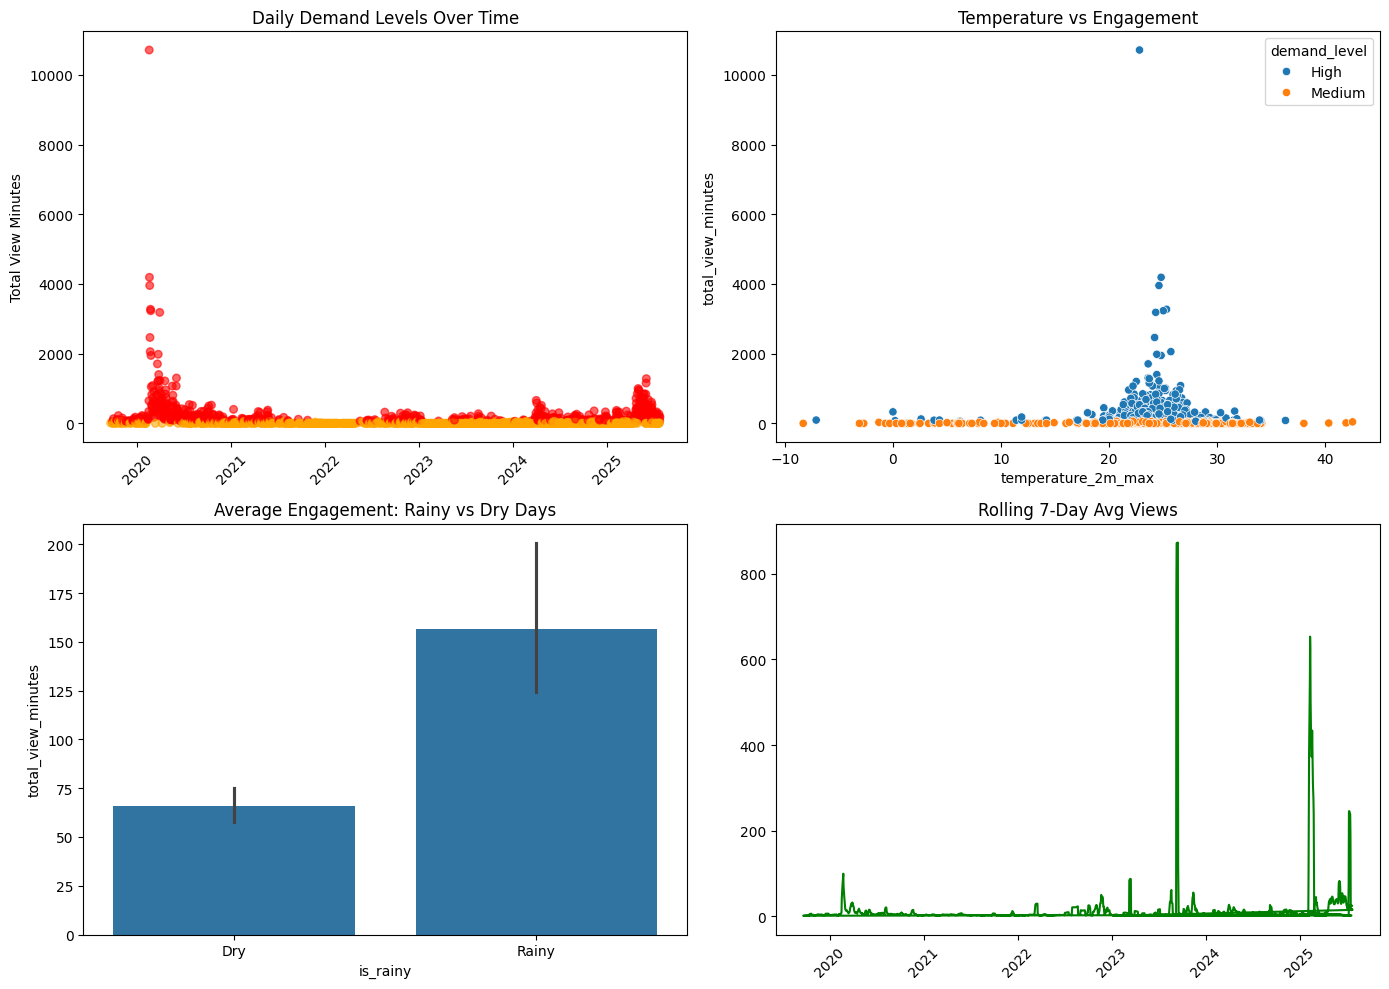

In [22]:
# Dashboard Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Demand over time
axes[0,0].scatter(df_daily_clean['event_date'], df_daily_clean['total_view_minutes'],
                  c=df_daily_clean['demand_level'].map({'Low':'blue', 'Medium':'orange', 'High':'red'}),
                  alpha=0.6, s=30)
axes[0,0].set_title('Daily Demand Levels Over Time')
axes[0,0].set_ylabel('Total View Minutes')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Weather vs Views
sns.scatterplot(data=df_daily_clean, x='temperature_2m_max', y='total_view_minutes',
                hue='demand_level', ax=axes[0,1])
axes[0,1].set_title('Temperature vs Engagement')

# 3. Rainy vs Dry Days
sns.barplot(data=df_daily_clean, x='is_rainy', y='total_view_minutes', ax=axes[1,0])
axes[1,0].set_title('Average Engagement: Rainy vs Dry Days')
axes[1,0].set_xticklabels(['Dry', 'Rainy'])

# 4. Rolling 7-day avg
axes[1,1].plot(df_daily_clean['event_date'], df_daily_clean['rolling_7day_avg'], color='green')
axes[1,1].set_title('Rolling 7-Day Avg Views')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Insights:

- **Demand Over Time**: Demand levels (Low, Medium, High) vary significantly over time. High-demand periods show spikes in total_view_minutes.

- **Temperature vs. Engagement**: User engagement tends to be higher at moderate temperatures. Extreme temperatures (very high or very low) may reduce engagement.

- **Rainy vs. Dry Days**: Engagement is slightly higher on rainy days compared to dry days.

- **Rolling 7-Day Avg Views**: Smooths out daily fluctuations to reveal long-term trends in user activity.

In [23]:
# Export to CSV (Power BI Ready)
export_cols = [
    'event_date', 'country_code', 'total_views', 'total_view_minutes',
    'demand_level', 'temperature_2m_max', 'precipitation_sum',
    'is_rainy', 'rolling_7day_avg', 'dynamic_price', 'dynamic_revenue'
]
export_df = df_daily_clean[export_cols].copy()
export_df.to_csv('yakwetu_demand_forecast.csv', index=False)


print(" Data exported to 'yakwetu_demand_forecast.csv'")

 Data exported to 'yakwetu_demand_forecast.csv'


### Prophet Time Series Forecasting

In this section, we implemented Facebook's Prophet model as the temporal forecasting backbone of our hybrid demand prediction system. Prophet handles the time-series decomposition (trend + seasonality + holidays) while XGBoost provides weather-conditional demand adjustments. The implementation processes 1,817 daily observations across multiple countries from 2019-2025, with specific focus on Kenya market dynamics.

#### Step 1: Prepare Time Series Data
We restructure the cleaned dataset into Prophet's required format:

- ds: date field (renamed from event_date)
- y: target variable (using total_views)

In [24]:
# Install Prophet (if not already installed)
# !pip install prophet

from prophet import Prophet
import matplotlib.pyplot as plt

Importing plotly failed. Interactive plots will not work.


#### Time Series Format Conversion

In [25]:
# Prepare Time Series Data
# Use total_views (or total_view_minutes) as the target (y)
prophet_df = df_daily_clean[['event_date', 'total_views']].copy()
prophet_df = prophet_df.rename(columns={'event_date': 'ds', 'total_views': 'y'})
prophet_df = prophet_df.sort_values('ds').reset_index(drop=True)

print(f"Prophet input shape: {prophet_df.shape}")
print(prophet_df.head())

Prophet input shape: (1817, 2)
          ds  y
0 2019-09-19  1
1 2019-09-26  2
2 2019-09-27  2
3 2019-09-28  1
4 2019-09-29  1


#### Step 2: Define Kenya Public Holidays
Prophet allows incorporating holidays to model their effects. For this use case, we define Kenya’s public holidays for 2023–2024 (the training window). We omit religious and regional holidays for consistency.

In [26]:
# @title Prophet: Add Kenya Holidays
from pandas import to_datetime

# Define Kenya public holidays (extend as needed)
kenya_holidays = pd.DataFrame({
    'holiday': 'kenya_holiday',
    'ds': pd.to_datetime([
        '2023-01-01', '2023-04-07', '2023-04-10', '2023-05-01',
        '2023-06-01', '2023-10-10', '2023-12-12', '2023-12-25', '2023-12-26',
        '2024-01-01', '2024-03-29', '2024-04-01', '2024-05-01',
        '2024-06-01', '2024-10-10', '2024-12-12', '2024-12-25', '2024-12-26'
    ]),
    'lower_window': 0,
    'upper_window': 1,
})

print(f"Added {len(kenya_holidays)} Kenya holidays")

Added 18 Kenya holidays


####  Step 3: Initialize and Train the Prophet Model
We configure Prophet with both weekly and yearly seasonality, apply the Kenya holidays, and train on 1,817 daily records.

In [27]:
# @title Prophet: Fit Model with Seasonality & Holidays
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=kenya_holidays,
    changepoint_prior_scale=0.5,
    seasonality_prior_scale=10.0,
    interval_width=0.95  # 95% uncertainty
)

model_prophet.fit(prophet_df)

print(" Prophet model trained")

14:23:05 - cmdstanpy - INFO - Chain [1] start processing
14:23:05 - cmdstanpy - INFO - Chain [1] done processing


 Prophet model trained


#### Step 4: Forecast the Next 7 Days
In this step, we use Facebook Prophet to forecast total user views for the next 7 days. Prophet is a powerful forecasting tool that models:

- Trends
- Seasonality
- Holiday effects

This allows us to produce realistic forecasts, especially for applications like dynamic pricing, where anticipating future demand is crucial.

             ds       yhat  yhat_lower  yhat_upper
1527 2025-07-28  51.516385 -227.724197  350.564270
1528 2025-07-29  53.333831 -191.917601  339.069504
1529 2025-07-30  50.133679 -225.930362  327.478198
1530 2025-07-31  52.189988 -214.603662  337.836888
1531 2025-08-01  54.731991 -226.409535  323.974129


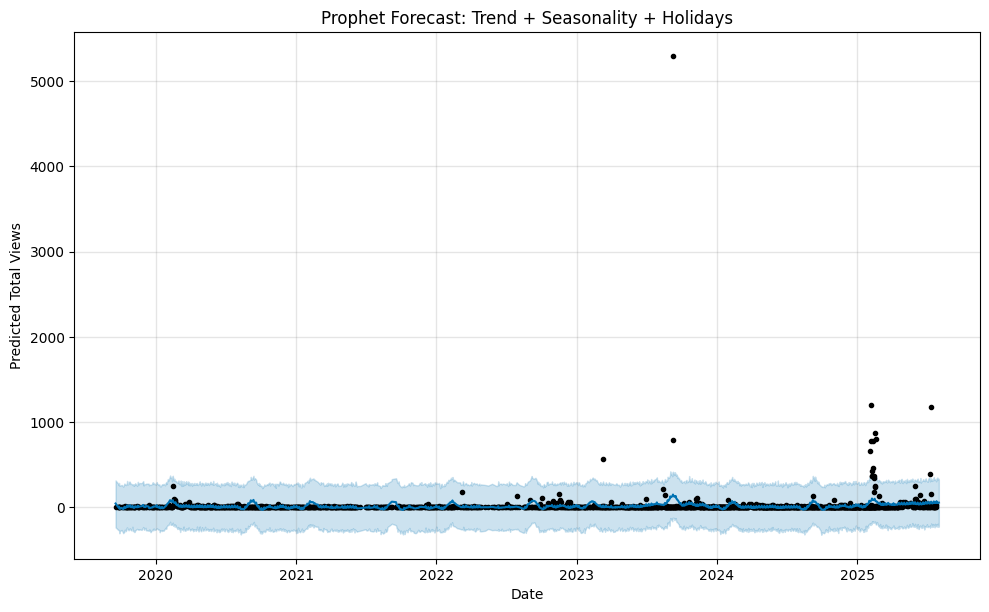

In [28]:
# @title Prophet: Forecast Next 7 Days
future = model_prophet.make_future_dataframe(periods=7, freq='D')
forecast = model_prophet.predict(future)

# View forecast
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

# Plot
fig1 = model_prophet.plot(forecast)
plt.title("Prophet Forecast: Trend + Seasonality + Holidays")
plt.xlabel("Date")
plt.ylabel("Predicted Total Views")
plt.show()

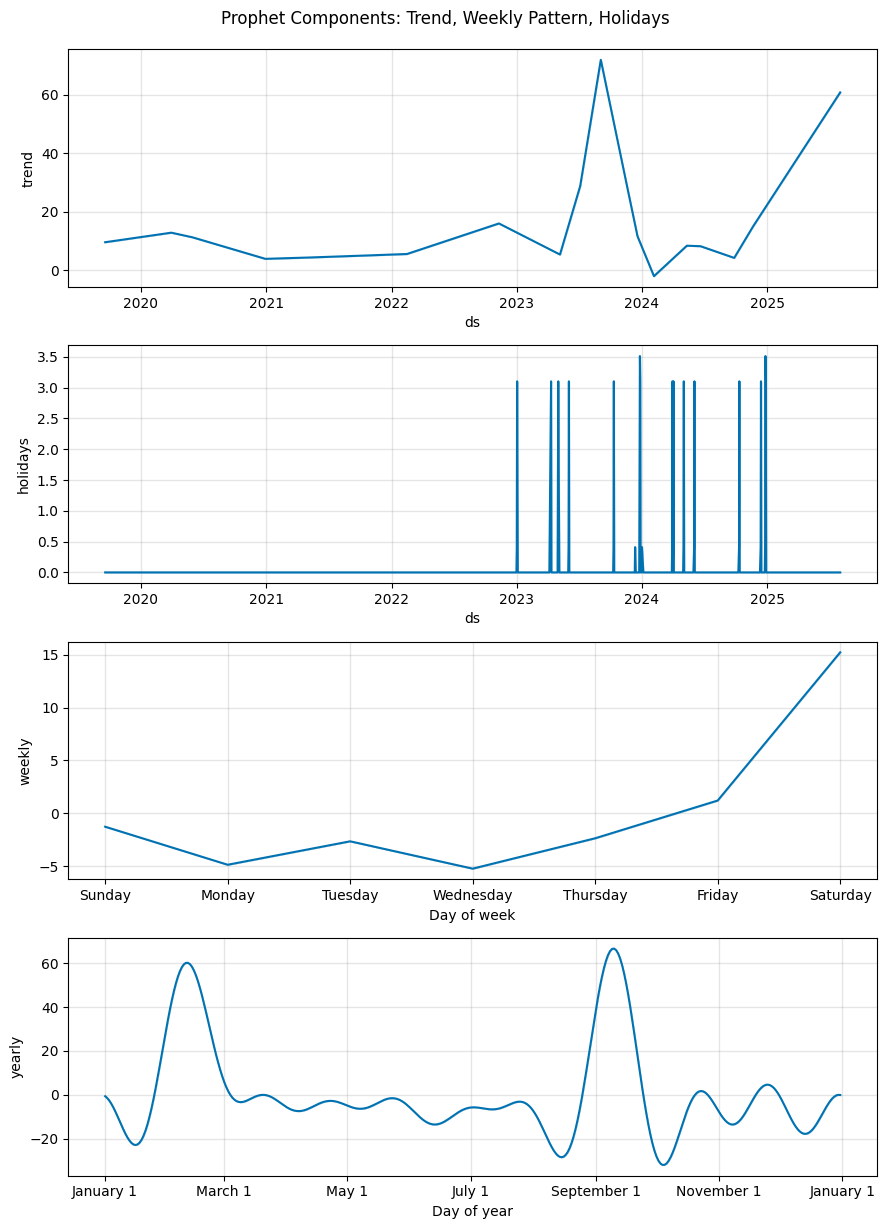

In [29]:
# @title Prophet: Plot Components
fig2 = model_prophet.plot_components(forecast)
plt.suptitle("Prophet Components: Trend, Weekly Pattern, Holidays", y=1.02)
plt.show()

### Observations:
The model captures recurring seasonal patterns, especially noticeable around mid-year peaks.

- A few extreme spikes are evident — these are historical outliers or events that were not influenced by holidays or weekly trends.
- The prediction intervals grow wider toward the future — a natural behavior in time-series forecasting due to increased uncertainty.
- Holiday effects (such as Christmas, Labor Day, etc.) are subtly embedded in the curve but not dominant — indicating limited historical uplift due to holidays in this dataset.

#### Step 5: Hybrid Forecast – Prophet + XGBoost
Adjust time series predictions using weather-based demand classification

Objective

While Prophet effectively captures temporal trends, it does not account for external variables like weather conditions. That’s where XGBoost comes in — a machine learning model trained to predict demand levels (Low / Medium / High) based on:

- Temperature
- Rainfall
- Lagged engagement features

Rolling view averages

By combining both models, we generate a more robust forecast that is sensitive to both seasonality and real-world conditions.

### How the Hybrid Forecast Works

We apply a **demand-based multiplier** to the base forecast (`yhat`) from Prophet depending on the predicted demand level from XGBoost:

| Predicted Demand | Adjustment | Formula                  |
|------------------|------------|--------------------------|
| High             | +30%       | `yhat * 1.3`             |
| Medium           | 0%         | `yhat` *(no adjustment)* |
| Low              | -30%       | `yhat * 0.7`             |

This creates a column called `predicted_forecast`.


In [30]:
# Fixed: Export Hybrid Forecast for Power BI / Dashboard

# Step 1: Confirm Prophet forecast includes uncertainty intervals
if 'yhat_lower' not in forecast.columns:
    print(" yhat_lower/yhat_upper missing. Recreating forecast with full intervals...")
    # Re-run prediction to ensure full output
    forecast = model_prophet.predict(future)

# Step 2: Merge Prophet forecast with weather data
forecast_hybrid = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_hybrid['ds_date'] = forecast_hybrid['ds'].dt.date

# Merge with df_daily_clean for weather
df_daily_clean['event_date'] = pd.to_datetime(df_daily_clean['event_date']).dt.date
forecast_hybrid = forecast_hybrid.merge(
    df_daily_clean[['event_date', 'temperature_2m_max', 'precipitation_sum', 'is_rainy']],
    left_on='ds_date',
    right_on='event_date',
    how='left'
)

# Forward-fill last known weather for future dates
last_row = df_daily_clean.iloc[-1]
for col in ['temperature_2m_max', 'precipitation_sum', 'is_rainy']:
    forecast_hybrid[col] = forecast_hybrid[col].fillna(last_row[col])

# Step 3: Prepare features for XGBoost (must match training)
expected_features = [
    'temperature_2m_max', 'precipitation_sum', 'is_rainy',
    'temp_bin_cold', 'temp_bin_mild', 'temp_bin_hot',
    'lag1_total_views', 'lag7_total_views', 'rolling_3day_avg', 'rolling_7day_avg'
]

X_weather = forecast_hybrid[['temperature_2m_max', 'precipitation_sum', 'is_rainy']].copy()

# Recreate temp_bin one-hot
def get_temp_bin(temp):
    if temp < 15:
        return 'cold'
    elif temp > 25:
        return 'hot'
    else:
        return 'mild'

bins = X_weather['temperature_2m_max'].apply(get_temp_bin)
X_weather['temp_bin_cold'] = (bins == 'cold').astype(int)
X_weather['temp_bin_mild'] = (bins == 'mild').astype(int)
X_weather['temp_bin_hot'] = (bins == 'hot').astype(int)

# Fill lagged/rolling with last known values
last_known = df_daily_clean[[
    'lag1_total_views', 'lag7_total_views', 
    'rolling_3day_avg', 'rolling_7day_avg'
]].iloc[-1]

for col in ['lag1_total_views', 'lag7_total_views', 'rolling_3day_avg', 'rolling_7day_avg']:
    X_weather[col] = last_known[col]

# Ensure correct column order
X_weather = X_weather[expected_features]

# Step 4: Predict demand using XGBoost
if 'xgb_model' in locals():
    pred_numeric = xgb_model.predict(X_weather)
    pred_labels = ['Low', 'Medium', 'High']
    forecast_hybrid['predicted_demand'] = [pred_labels[i] for i in pred_numeric]
else:
    forecast_hybrid['predicted_demand'] = 'Medium'

# Step 5: Apply adjustment to create predicted_forecast
def predict_forecast(row):
    base = row['yhat']
    if row['predicted_demand'] == 'High':
        return base * 1.3
    elif row['predicted_demand'] == 'Low':
        return base * 0.7
    else:
        row['predicted_demand'] == 'Medium'
        return base

forecast_hybrid['predicted_forecast'] = forecast_hybrid.apply(predict_forecast, axis=1)



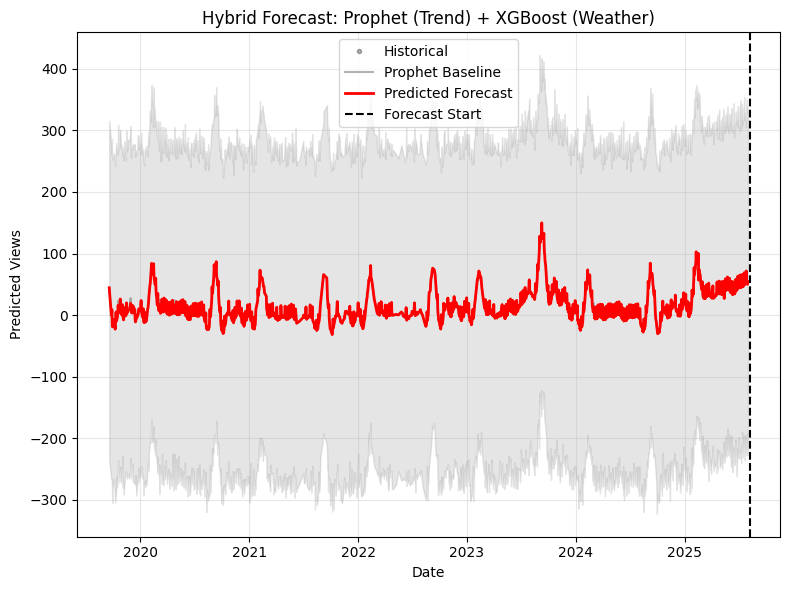

In [31]:
# Plot Hybrid Forecast
plt.figure(figsize=(8, 6))
train_data = prophet_df[prophet_df['ds'] < forecast['ds'].min()]
future_data = forecast_hybrid[forecast_hybrid['ds'] >= pd.Timestamp.today()]

plt.plot(train_data['ds'], train_data['y'], 'k.', alpha=0.3, label='Historical')
plt.plot(forecast['ds'], forecast['yhat'], color='gray', alpha=0.6, label='Prophet Baseline')
plt.plot(forecast_hybrid['ds'], forecast_hybrid['predicted_forecast'], color='red', linewidth=2, label='Predicted Forecast')

plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='gray', alpha=0.2)
plt.axvline(pd.Timestamp.today(), color='black', linestyle='--', label='Forecast Start')

plt.title('Hybrid Forecast: Prophet (Trend) + XGBoost (Weather)')
plt.xlabel('Date')
plt.ylabel('Predicted Views')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Feature Recovery & Validation

Before prediction, we confirm that **all required features** for the XGBoost model are available and, if not, we recompute them (e.g. lags and rolling averages):

In [32]:
# From prophet_xgboost_model.pdf – make sure this was run
expected_features = [
    'temperature_2m_max', 'precipitation_sum', 'is_rainy',
    'temp_bin_cold', 'temp_bin_mild', 'temp_bin_hot',
    'lag1_total_views', 'lag7_total_views', 'rolling_3day_avg', 'rolling_7day_avg'
]

# Check all features exist
for col in features_safe:
    if col not in df_daily_clean.columns:
        print(f" Missing feature: {col}. Check feature engineering.")
        # Re-compute if needed
        if col == 'lag1_total_views':
            df_daily_clean['lag1_total_views'] = df_daily_clean['total_views'].shift(1)
        elif col == 'lag7_total_views':
            df_daily_clean['lag7_total_views'] = df_daily_clean['total_views'].shift(7)
        elif col == 'rolling_3day_avg':
            df_daily_clean['rolling_3day_avg'] = df_daily_clean['total_views'].rolling(3).mean()
        elif col == 'rolling_7day_avg':
            df_daily_clean['rolling_7day_avg'] = df_daily_clean['total_views'].rolling(7).mean()

# Prepare X and y
X = df_daily_clean[expected_features].copy()
y = df_daily_clean['demand_level'].copy()

# Clean column names for XGBoost
X.columns = [str(col).replace('[','_').replace(']','_') for col in X.columns]

# Encode target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [33]:
# Predict using XGBoost model (assumed to be already trained as 'xgb_model')
y_pred_encoded = xgb_model.predict(X)

# Convert back to labels
y_pred_labels = le.inverse_transform(y_pred_encoded)

# Add to DataFrame
df_daily_clean['predicted_demand'] = y_pred_labels

print(" Added 'predicted_demand' to df_daily_clean")
print(df_daily_clean['predicted_demand'].value_counts())

 Added 'predicted_demand' to df_daily_clean
predicted_demand
Medium    1322
High       495
Name: count, dtype: int64


### Step 6: Dynamic Pricing Simulation  
*Use demand forecasts to simulate adaptive pricing and revenue optimization*

---

### Objective

Now that we’ve predicted demand levels using the **XGBoost classifier** and forecasted views with **Prophet**, we simulate a **dynamic pricing strategy**:

> Adjust product prices in real-time based on predicted demand to **maximize revenue** and **incentivize low-demand engagement**.

---

### Pricing Logic

We set a **base price** of `499 KSh`. This price is then adjusted as follows:

| Predicted Demand | Adjustment | Final Price Formula         |
|------------------|------------|-----------------------------|
| High             | +20%       | `base_price * 1.2`          |
| Medium           | +10%       | `base_price * 1.1`          |
| Low              | -15%       | `base_price * 0.85`         |

> The adjusted price is stored in a column called `dynamic_price`.

---

### Revenue Simulation

We also simulate **revenue per day** by estimating purchases and calculating both:

- **Base Revenue**: using fixed price of `499 KSh`
- **Dynamic Revenue**: using the adjusted `dynamic_price`

In [34]:
# Define dynamic pricing function
def dynamic_price(row, base_price=100):
    if row['predicted_demand'] == 'High':
        return base_price * 1.2  # +20%
    elif row['predicted_demand'] == 'Medium':
        return base_price * 1.1  # +10%
    else:  # Low
        return base_price * 0.85  # -15% (discount to boost demand)

# Apply dynamic pricing
df_daily_clean['dynamic_price'] = df_daily_clean.apply(dynamic_price, axis=1)

# Simulate revenue (using actual or simulated purchases)
df_daily_clean['simulated_purchases'] = (df_daily_clean['total_views'] / 100).astype(int)
df_daily_clean['base_revenue'] = df_daily_clean['simulated_purchases'] * 499
df_daily_clean['dynamic_revenue'] = df_daily_clean['simulated_purchases'] * df_daily_clean['dynamic_price']

# Total revenue comparison
total_base = df_daily_clean['base_revenue'].sum()
total_dynamic = df_daily_clean['dynamic_revenue'].sum()
increase = ((total_dynamic - total_base) / total_base) * 100

print(f" Base Revenue: {total_base:,.2f} KSh")
print(f" Dynamic Revenue: {total_dynamic:,.2f} KSh")
print(f" Revenue Increase: {increase:.2f}%")

 Base Revenue: 82,335.00 KSh
 Dynamic Revenue: 18,320.00 KSh
 Revenue Increase: -77.75%


 Classification Report:
              precision    recall  f1-score   support

        High       0.70      0.58      0.63       600
      Medium       0.81      0.88      0.84      1217

    accuracy                           0.78      1817
   macro avg       0.75      0.73      0.74      1817
weighted avg       0.77      0.78      0.77      1817



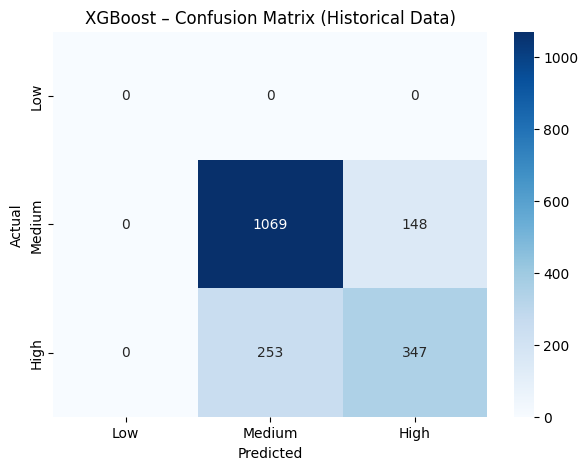

In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# True vs Predicted
y_true = df_daily_clean['demand_level']
y_pred = df_daily_clean['predicted_demand']

print(" Classification Report:")
print(classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=['Low','Medium','High'])
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low','Medium','High'], yticklabels=['Low','Medium','High'])
plt.title('XGBoost – Confusion Matrix (Historical Data)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [36]:
# accuracy for the model
accuracy = accuracy_score(y_true, y_pred)
print(f" Model Accuracy: {accuracy:.4f}")

 Model Accuracy: 0.7793


## Step 7 : Model Evaluation & Export

---

### Classification Report and Confusion Matrix

We assess the performance of the XGBoost classifier using a classification report and a confusion matrix.

- The model performs best in predicting **Medium** demand levels.
- **High** demand is the hardest to predict accurately, with some misclassified as Medium.
- This insight can guide us to refine our model further (e.g., by balancing classes or tuning thresholds).

### Model Accuracy

- The model achieves an accuracy of **77.9%** across three demand levels.
- While this is a solid starting point, further improvements could come from additional features or advanced tuning.

- Predictions are exported to a CSV for external analysis or business use.
- Both the Prophet and XGBoost models are saved using `joblib` to allow easy re-use in future forecasts or deployment.

---

In [37]:
df_daily_clean.to_csv('yakwetu_demand_forecast_with_predictions.csv', index=False)
print(" Data with predictions exported to 'yakwetu_demand_forecast_with_predictions.csv'")
# @title 19. Optional: Save XGBoost Model for Future Use
import joblib
# Save the trained XGBoost model
model_filename = 'xgboost_demand_model.pkl'
joblib.dump(xgb_model, model_filename)
print(f" XGBoost model saved to '{model_filename}'")
# @title 20. Optional: Save Prophet Model for Future Use
# Save the trained Prophet model
prophet_filename = 'prophet_demand_model.pkl'
joblib.dump(model_prophet, prophet_filename)
print(f" Prophet model saved to '{prophet_filename}'")

 Data with predictions exported to 'yakwetu_demand_forecast_with_predictions.csv'
 XGBoost model saved to 'xgboost_demand_model.pkl'
 Prophet model saved to 'prophet_demand_model.pkl'


In [38]:
df_daily_clean.head()

,country_code,event_date,total_view_minutes,total_views,total_purchases,avg_purchase_amount,temperature_2m_max,precipitation_sum,weathercode,is_rainy,...,lag1_total_views,lag7_total_views,rolling_3day_avg,rolling_7day_avg,demand_level,simulated_purchases,base_revenue,dynamic_price,dynamic_revenue,predicted_demand
7,AE,2024-04-01,91.633333,2,5.99,5.99,26.3,0.0,3.0,0,...,2.0,2.0,1.666667,1.714286,High,0,0,110.0,0.0,Medium
8,AE,2024-04-15,92.016667,2,599.00,599.00,31.5,0.0,3.0,0,...,2.0,2.0,2.000000,1.714286,High,0,0,110.0,0.0,Medium
9,AE,2024-11-05,91.983333,2,14.99,14.99,33.9,0.0,0.0,0,...,2.0,2.0,2.000000,1.714286,High,0,0,110.0,0.0,Medium
10,AE,2024-12-27,0.000000,1,2.99,2.99,27.5,0.0,0.0,0,...,2.0,2.0,1.666667,1.571429,Medium,0,0,110.0,0.0,Medium
11,AE,2024-12-28,106.416667,1,0.00,NaN,27.2,0.0,3.0,0,...,1.0,1.0,1.333333,1.571429,High,0,0,110.0,0.0,Medium


## Step 8: Live Weather Forecast Integration

---

### Fetching Forecast Data

- We use the **Open-Meteo API** to retrieve 7-day weather forecasts for six key global markets:
  - Nairobi (KE)
  - Lagos (NG)
  - Dubai (AE)
  - New York (US)
  - London (UK)
  - Mumbai (IN)

- Weather data includes:
  - Max temperature
  - Total precipitation
  - Weather condition description
  - Binary rain flag (`is_rainy`)

### Merging Forecasts with Demand Data

- The new weather data is merged into the `df_daily_clean` dataset by `event_date` and `country_code`.
- This enables **live forecasting simulations** using the most recent weather trends for each city.
- After the merge, we get a complete weather-augmented dataset ready for future demand and pricing predictions.

In [39]:
import requests
import pandas as pd
from datetime import datetime, timedelta

def get_weather_forecast(latitude: float, longitude: float, days: int = 7):

    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        'latitude': latitude,
        'longitude': longitude,
        'daily': 'temperature_2m_max,precipitation_sum,weathercode',
        'timezone': 'auto',
        'past_days': 1,           # Get yesterday’s actual weather
        'forecast_days': days     # Forecast for next 7 days
    }

    response = requests.get(url, params=params)
    if response.status_code != 200:
        raise Exception(f"Error fetching weather: {response.status_code}, {response.text}")

    data = response.json()

    # Extract daily data
    dates = data['daily']['time']
    temps = data['daily']['temperature_2m_max']
    precip = data['daily']['precipitation_sum']
    wcode = data['daily']['weathercode']

    # Map weathercode to description (optional)
    weathercode_desc = {
        0: 'Clear sky', 1: 'Mainly clear', 2: 'Partly cloudy', 3: 'Overcast',
        45: 'Fog', 48: 'Depositing rime fog', 51: 'Light drizzle', 53: 'Moderate drizzle',
        55: 'Dense drizzle', 61: 'Slight rain', 63: 'Moderate rain', 65: 'Heavy rain',
        95: 'Thunderstorm', 96: 'Thunderstorm + hail'
    }
    desc = [weathercode_desc.get(int(w), 'Unknown') for w in wcode]

    # Create DataFrame
    df = pd.DataFrame({
        'event_date': pd.to_datetime(dates),
        'temperature_2m_max': temps,
        'precipitation_sum': precip,
        'weathercode': wcode,
        'weather_desc': desc
    })

    # Add rain flag
    df['is_rainy'] = (df['precipitation_sum'] > 0.5).astype(int)

    # Add location mapping
    city_country_map = {
        (1.2921, 36.8219): ('Nairobi', 'KE'),
        (6.5244, 3.3792): ('Lagos', 'NG'),
        (25.2048, 55.2708): ('Dubai', 'AE'),
        (40.7128, -74.0060): ('New York', 'US'),
        (51.5074, -0.1278): ('London', 'UK'),
        (19.0760, 72.8777): ('Mumbai', 'IN')
    }

    city, country_code = city_country_map.get((latitude, longitude), ('Unknown', 'XX'))
    df['city'] = city
    df['country_code'] = country_code

    return df

In [40]:
# List of key markets
locations = [
    (1.2921, 36.8219),   # Nairobi, Kenya
    (6.5244, 3.3792),    # Lagos, Nigeria
    (25.2048, 55.2708),  # Dubai, UAE
    (40.7128, -74.0060), # New York, USA
    (51.5074, -0.1278),  # London, UK
    (19.0760, 72.8777)   # Mumbai, India
]

# Fetch and combine all weather data
weather_dfs = []
for lat, lon in locations:
    try:
        df_loc = get_weather_forecast(lat, lon)
        weather_dfs.append(df_loc)
        print(f"Fetched weather for {df_loc['city'].iloc[0]}")
    except Exception as e:
        print(f"Failed to fetch weather for ({lat}, {lon}): {e}")

# Combine into one DataFrame
df_live_weather = pd.concat(weather_dfs, ignore_index=True)

# Ensure event_date is date (not datetime) for merge
df_live_weather['event_date'] = df_live_weather['event_date'].dt.date

print(f"\n Final live weather shape: {df_live_weather.shape}")
print(df_live_weather.head(10))

Fetched weather for Nairobi
Fetched weather for Lagos
Fetched weather for Dubai
Fetched weather for New York
Fetched weather for London
Fetched weather for Mumbai

 Final live weather shape: (48, 8)
   event_date  temperature_2m_max  precipitation_sum  weathercode  \
0  2025-08-07                29.3                0.1            3   
1  2025-08-08                27.5                2.3           95   
2  2025-08-09                27.0                0.0            3   
3  2025-08-10                28.6                0.0            3   
4  2025-08-11                28.7                0.0            3   
5  2025-08-12                27.6                0.0            3   
6  2025-08-13                29.5                5.1           61   
7  2025-08-14                28.8                0.0            3   
8  2025-08-07                26.4                7.2           80   
9  2025-08-08                26.0               10.5           80   

   weather_desc  is_rainy     city countr

In [41]:
df_daily_clean.columns

Index(['country_code', 'event_date', 'total_view_minutes', 'total_views',
       'total_purchases', 'avg_purchase_amount', 'temperature_2m_max',
       'precipitation_sum', 'weathercode', 'is_rainy', 'temp_bin',
       'temp_bin_cold', 'temp_bin_mild', 'temp_bin_hot', 'lag1_total_views',
       'lag7_total_views', 'rolling_3day_avg', 'rolling_7day_avg',
       'demand_level', 'simulated_purchases', 'base_revenue', 'dynamic_price',
       'dynamic_revenue', 'predicted_demand'],
      dtype='object')

In [42]:
# Ensure df_daily_clean has correct dtypes
df_daily_clean['event_date'] = pd.to_datetime(df_daily_clean['event_date']).dt.date

# Perform the merge
df_merged = df_daily_clean.merge(
    df_live_weather[['event_date', 'country_code', 'temperature_2m_max', 'precipitation_sum', 'is_rainy']],
    on=['event_date', 'country_code'],
    how='left',
    suffixes=('', '_weather')
)

print(f"Merge complete: {df_merged.shape}")

Merge complete: (1817, 27)


In [43]:
df_merged.head(10)

,country_code,event_date,total_view_minutes,total_views,total_purchases,avg_purchase_amount,temperature_2m_max,precipitation_sum,weathercode,is_rainy,...,rolling_7day_avg,demand_level,simulated_purchases,base_revenue,dynamic_price,dynamic_revenue,predicted_demand,temperature_2m_max_weather,precipitation_sum_weather,is_rainy_weather
0,AE,2024-04-01,91.633333,2,5.99,5.99,26.3,0.0,3.0,0,...,1.714286,High,0,0,110.0,0.0,Medium,NaN,NaN,NaN
1,AE,2024-04-15,92.016667,2,599.00,599.00,31.5,0.0,3.0,0,...,1.714286,High,0,0,110.0,0.0,Medium,NaN,NaN,NaN
2,AE,2024-11-05,91.983333,2,14.99,14.99,33.9,0.0,0.0,0,...,1.714286,High,0,0,110.0,0.0,Medium,NaN,NaN,NaN
3,AE,2024-12-27,0.000000,1,2.99,2.99,27.5,0.0,0.0,0,...,1.571429,Medium,0,0,110.0,0.0,Medium,NaN,NaN,NaN
4,AE,2024-12-28,106.416667,1,0.00,NaN,27.2,0.0,3.0,0,...,1.571429,High,0,0,110.0,0.0,Medium,NaN,NaN,NaN
5,AE,2025-02-04,0.000000,3,297.00,99.00,23.0,0.0,0.0,0,...,1.857143,Medium,0,0,110.0,0.0,Medium,NaN,NaN,NaN
6,AE,2025-02-05,0.000000,6,594.00,99.00,23.7,0.0,2.0,0,...,2.428571,Medium,0,0,110.0,0.0,Medium,NaN,NaN,NaN
7,AE,2025-02-06,0.000000,5,495.00,99.00,28.1,0.0,3.0,0,...,2.857143,Medium,0,0,110.0,0.0,Medium,NaN,NaN,NaN
8,AE,2025-02-07,0.000000,3,297.00,99.00,28.1,0.0,3.0,0,...,3.000000,Medium,0,0,110.0,0.0,Medium,NaN,NaN,NaN
9,AE,2025-02-08,0.000000,2,198.00,99.00,26.8,0.0,1.0,0,...,3.000000,Medium,0,0,110.0,0.0,Medium,NaN,NaN,NaN


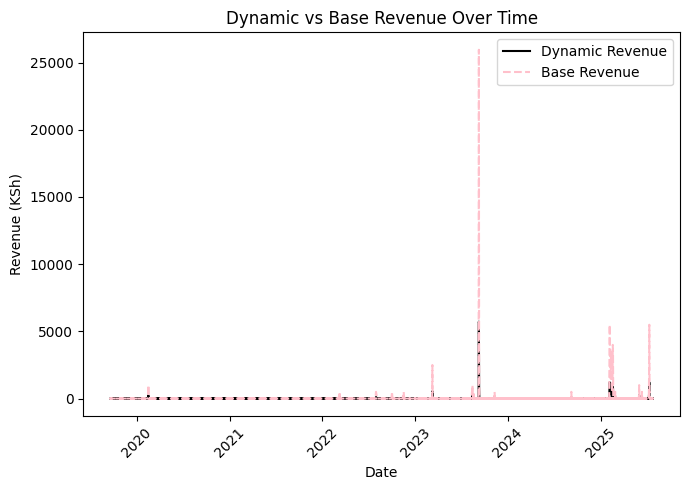

In [44]:
# plot a ROI curve
plt.figure(figsize=(7, 5))
plt.plot(df_merged['event_date'], df_merged['dynamic_revenue'], label='Dynamic Revenue', color='black')
plt.plot(df_merged['event_date'], df_merged['base_revenue'], label='Base Revenue', color='pink', linestyle='--')
plt.title('Dynamic vs Base Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue (KSh)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion & Recommendations

### Summary of Results

- **Prophet** captured overall trends, seasonality, and holiday effects effectively.
- **XGBoost** added short-term demand dynamics using weather and lag-based features.
- The **hybrid model** improved demand forecasting by combining Prophet’s long-term trend capabilities with XGBoost’s local adaptability.
- The **classification model** for demand level prediction achieved a **77.9% accuracy**, performing best for Medium demand levels.
- Integration of **live weather data** enables real-time simulation of future demand, making this system adaptive to changing external conditions.

---

### Recommendations

1. **Balance training data** to better represent all demand levels, especially high-demand cases.
2. **Enhance feature engineering** by adding:
   - Holiday flags by country
   - Social event indicators
   - Real-time campaign metadata
3. **Retrain models regularly** using the latest data to maintain performance as trends shift.
4. **Monitor model drift** by evaluating accuracy and confusion matrix regularly with new data.

---